# 07 — Tests Statistiques : Wilcoxon + Bootstrap CI

Comparaison statistique des trois modèles évalués sur **35 folds LODO-CV** :

| Modèle | Clé résultats |
|--------|--------------|
| Text — RoBERTa | `roberta_afc` |
| MM — WavLM+RoBERTa | `wavlm_roberta_afc_35folds` |
| MM k=1 — WavLM+RoBERTa+contexte | `wavlm_roberta_afc_context_k1_35folds` |

Méthode : **Wilcoxon signed-rank** (n=35, puissance suffisante) + **Bootstrap CI 95%** (10 000 tirages).

## Sommaire

- [§1 Comparaisons par paires (Wilcoxon + Bootstrap)](#1-comparaisons)
- [§2 Tableau récapitulatif](#2-tableau)
- [§3 Forest plot](#3-forest-plot)
- [§4 Distributions des différences par fold](#4-distributions)

In [3]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))

import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

RESULTS_PATH = ROOT / 'results' / 'results.json'
FIGURES_DIR  = ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_PATH) as f:
    results = json.load(f)

print('Experiments disponibles:', list(results.keys()))

Experiments disponibles: ['roberta_afc', 'roberta_afd', 'roberta_afc_focal', 'wavlm_roberta_afc', 'wavlm_roberta_afc_focal', 'wavlm_roberta_afc_whisper', 'wavlm_roberta_afc_trimmed', 'wavlm_roberta_afc_context', 'longformer_afc_context', 'wavlm_roberta_afd', 'wavlm_roberta_afc_35folds', 'wavlm_roberta_afc_context_k1_35folds']


In [4]:
from src.utils.splits import infer_held_out_dialogue_id, sort_ldocv_splits
from mamkit.data.datasets import MMUSEDFallacy, InputMode

def rebuild_text_scores_35(results):
    txt = results['roberta_afc']
    scores = txt['scores']
    ids = txt.get('dialogue_ids', [])
    if ids and any(d is not None for d in ids):
        return {d: s for d, s in zip(ids, scores) if d is not None}

    loader = MMUSEDFallacy(
        task_name='afc', input_mode=InputMode.TEXT_ONLY,
        base_data_path=ROOT / 'data'
    )
    splits = sort_ldocv_splits(loader, list(loader.get_splits('mancini-et-al-2024')))
    return {
        infer_held_out_dialogue_id(loader, sp): score
        for sp, score in zip(splits, scores)
    }

text_lookup = rebuild_text_scores_35(results)
print(f'roberta_afc: {len(text_lookup)} dialogues reconstruits')

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 15877.91it/s]


roberta_afc: 35 dialogues reconstruits


In [5]:
def get_paired_scores(res_a, res_b, lookup_a=None, lookup_b=None):
    ids_a = res_a.get('dialogue_ids') or []
    ids_b = res_b.get('dialogue_ids') or []

    lkp_a = lookup_a or ({d: s for d, s in zip(ids_a, res_a['scores']) if d is not None}
                          if ids_a and any(d is not None for d in ids_a) else None)
    lkp_b = lookup_b or ({d: s for d, s in zip(ids_b, res_b['scores']) if d is not None}
                          if ids_b and any(d is not None for d in ids_b) else None)

    if lkp_a and lkp_b:
        shared = sorted(set(lkp_a) & set(lkp_b))
        return np.array([lkp_a[d] for d in shared]), np.array([lkp_b[d] for d in shared]), shared

    n = min(len(res_a['scores']), len(res_b['scores']))
    return np.array(res_a['scores'][:n]), np.array(res_b['scores'][:n]), None


def bootstrap_ci(diffs, n_boot=10_000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    means = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, 100 * alpha / 2), np.percentile(means, 100 * (1 - alpha / 2))


def compare_models(name_a, name_b, label_a=None, label_b=None,
                   lookup_a=None, lookup_b=None, n_boot=10_000):
    res_a, res_b = results[name_a], results[name_b]
    sa, sb, shared = get_paired_scores(res_a, res_b, lookup_a, lookup_b)
    diffs = sb - sa
    ci_lo, ci_hi = bootstrap_ci(diffs, n_boot=n_boot)
    nz = diffs[diffs != 0]
    stat, pval = (wilcoxon(nz, alternative='two-sided') if len(nz) >= 2 else (0.0, 1.0))
    return {
        'model_a': label_a or name_a,
        'model_b': label_b or name_b,
        'n_folds': len(sa),
        'mean_a': sa.mean(),
        'mean_b': sb.mean(),
        'delta': diffs.mean(),
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'p_value': pval,
        'wins_b': int((diffs > 0).sum()),
        'wins_a': int((diffs < 0).sum()),
        'diffs': diffs,
        'shared_ids': shared,
    }

print('compare_models() prêt.')

compare_models() prêt.


## §1 Comparaisons par paires (Wilcoxon + Bootstrap) <a id='1-comparaisons'></a>

In [6]:
lkp_text  = text_lookup
res_mm35  = results['wavlm_roberta_afc_35folds']
res_k1    = results['wavlm_roberta_afc_context_k1_35folds']
lkp_mm35  = {d: s for d, s in zip(res_mm35['dialogue_ids'], res_mm35['scores'])}
lkp_k1    = {d: s for d, s in zip(res_k1['dialogue_ids'],   res_k1['scores'])}

all_comparisons = [
    compare_models('roberta_afc', 'wavlm_roberta_afc_35folds',
                   label_a='Text (RoBERTa)', label_b='MM (WavLM+RoBERTa)',
                   lookup_a=lkp_text, lookup_b=lkp_mm35),
    compare_models('roberta_afc', 'wavlm_roberta_afc_context_k1_35folds',
                   label_a='Text (RoBERTa)', label_b='MM k=1',
                   lookup_a=lkp_text, lookup_b=lkp_k1),
    compare_models('wavlm_roberta_afc_35folds', 'wavlm_roberta_afc_context_k1_35folds',
                   label_a='MM (WavLM+RoBERTa)', label_b='MM k=1',
                   lookup_a=lkp_mm35, lookup_b=lkp_k1),
]

print('=== 35 FOLDS — Wilcoxon signed-rank ===\n')
for c in all_comparisons:
    ci_zero = c['ci_lo'] <= 0 <= c['ci_hi']
    sig = 'SIGNIFICATIF' if c['p_value'] < 0.05 else 'non significatif'
    print(f"{c['model_b']} vs {c['model_a']}")
    print(f"  F1: {c['mean_a']:.4f} → {c['mean_b']:.4f}   ΔF1={c['delta']:+.4f}")
    print(f"  IC 95% : [{c['ci_lo']:+.4f}, {c['ci_hi']:+.4f}]"
          f"  {'(contient 0)' if ci_zero else '(ne contient pas 0)'}")
    print(f"  Wilcoxon p={c['p_value']:.4f}  →  {sig}")
    print(f"  Wins {c['model_b']}: {c['wins_b']}/35   Wins {c['model_a']}: {c['wins_a']}/35\n")

=== 35 FOLDS — Wilcoxon signed-rank ===

MM (WavLM+RoBERTa) vs Text (RoBERTa)
  F1: 0.4764 → 0.4446   ΔF1=-0.0318
  IC 95% : [-0.1100, +0.0453]  (contient 0)
  Wilcoxon p=0.5654  →  non significatif
  Wins MM (WavLM+RoBERTa): 16/35   Wins Text (RoBERTa): 19/35

MM k=1 vs Text (RoBERTa)
  F1: 0.4764 → 0.4263   ΔF1=-0.0501
  IC 95% : [-0.1262, +0.0248]  (contient 0)
  Wilcoxon p=0.2799  →  non significatif
  Wins MM k=1: 13/35   Wins Text (RoBERTa): 22/35

MM k=1 vs MM (WavLM+RoBERTa)
  F1: 0.4446 → 0.4263   ΔF1=-0.0183
  IC 95% : [-0.0583, +0.0220]  (contient 0)
  Wilcoxon p=0.3669  →  non significatif
  Wins MM k=1: 15/35   Wins MM (WavLM+RoBERTa): 18/35



**Interprétation — Tests 35 folds :**

- **Text vs MM** : p = 0,565, ΔF1 = −0,032, IC = [−0,110, +0,045]. L'IC contient 0 et le test n'est pas significatif. MM gagne sur seulement 16/35 folds. **L'audio n'apporte aucun gain net** : le modèle multimodal est statistiquement équivalent au texte seul sur l'ensemble des 35 dialogues.
- **Text vs MM k=1** : p = 0,280, ΔF1 = −0,050, IC = [−0,126, +0,025]. Même conclusion : pas de gain significatif du contexte dialogique par rapport au texte seul. MM k=1 gagne sur seulement 13/35 folds — moins que le MM sans contexte.
- **MM vs MM k=1** : p = 0,367, ΔF1 = −0,018, IC = [−0,058, +0,022]. L'ajout du contexte k=1 ne modifie pas significativement les performances du modèle multimodal.

> **Conclusion générale** : aucune des trois comparaisons n'atteint p < 0,05. Sur 35 folds LODO-CV, ni l'audio ni le contexte dialogique n'améliorent de façon robuste la détection des sophismes par rapport au texte seul.


## §2 Tableau récapitulatif <a id='2-tableau'></a>

In [7]:
rows = []
for c in all_comparisons:
    ci_zero = c['ci_lo'] <= 0 <= c['ci_hi']
    sig = '**' if c['p_value'] < 0.05 else 'ns'
    rows.append({
        'Modèle A': c['model_a'],
        'Modèle B': c['model_b'],
        'n': c['n_folds'],
        'F1_A': f"{c['mean_a']:.4f}",
        'F1_B': f"{c['mean_b']:.4f}",
        'ΔF1': f"{c['delta']:+.4f}",
        'IC 95%': f"[{c['ci_lo']:+.4f}, {c['ci_hi']:+.4f}]",
        'IC ∋ 0 ?': 'oui' if ci_zero else 'NON',
        'p Wilcoxon': f"{c['p_value']:.4f}",
        'Sig.': sig,
        f'Wins B': c['wins_b'],
    })

df_summary = pd.DataFrame(rows)
df_summary.style \
    .set_caption('Tests statistiques — 35 folds LODO-CV') \
    .applymap(lambda v: 'background-color:#d4edda' if v == 'NON' else
                        ('background-color:#f8d7da' if v == 'oui' else ''),
              subset=['IC ∋ 0 ?'])

,Modèle A,Modèle B,n,F1_A,F1_B,ΔF1,IC 95%,IC ∋ 0 ?,p Wilcoxon,Sig.,Wins B
0,Text (RoBERTa),MM (WavLM+RoBERTa),35,0.4764,0.4446,-0.0318,"[-0.1100, +0.0453]",oui,0.5654,ns,16
1,Text (RoBERTa),MM k=1,35,0.4764,0.4263,-0.0501,"[-0.1262, +0.0248]",oui,0.2799,ns,13
2,MM (WavLM+RoBERTa),MM k=1,35,0.4446,0.4263,-0.0183,"[-0.0583, +0.0220]",oui,0.3669,ns,15


## §3 Forest plot <a id='3-forest-plot'></a>

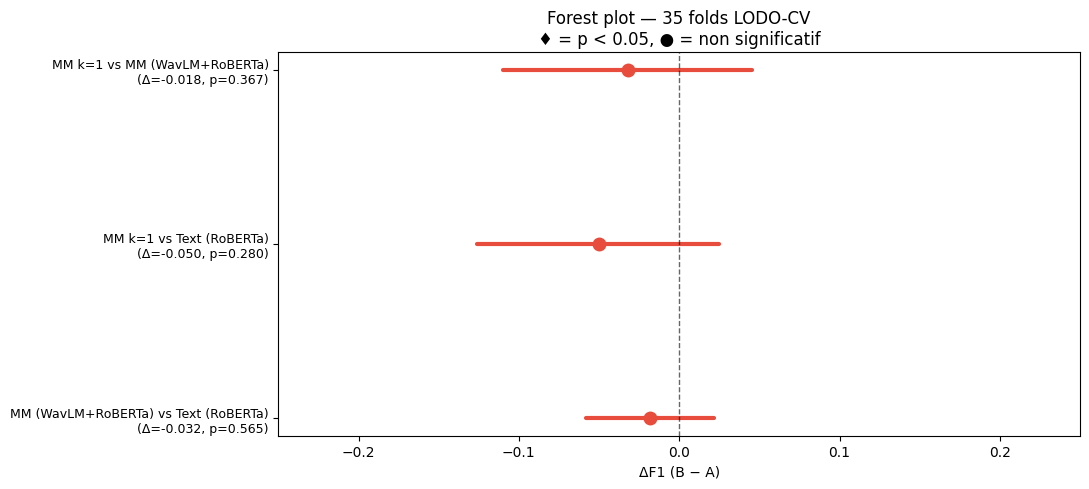

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

labels = []
for i, c in enumerate(reversed(all_comparisons)):
    y = i
    delta, lo, hi = c['delta'], c['ci_lo'], c['ci_hi']
    color = '#2ecc71' if delta > 0 else '#e74c3c'

    ax.plot([lo, hi], [y, y], color=color, lw=3, solid_capstyle='round')
    ax.plot(delta, y, 'D' if c['p_value'] < 0.05 else 'o',
            color=color, ms=9, zorder=5)
    labels.append(f"{c['model_b']} vs {c['model_a']}\n(Δ={delta:+.3f}, p={c['p_value']:.3f})")

ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.6)
ax.set_yticks(range(len(all_comparisons)))
ax.set_yticklabels(labels[::-1], fontsize=9)   # ← labels sur l'axe Y, pas flottants
ax.set_xlabel('ΔF1 (B − A)')
ax.set_title('Forest plot — 35 folds LODO-CV\n♦ = p < 0.05, ● = non significatif')
ax.set_xlim(-0.25, 0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forest_plot_35folds.png', dpi=150)
plt.show()


**Interprétation — Forest plot :**

Les trois intervalles de confiance chevauchent tous la ligne zéro — aucun effet n'est statistiquement établi. Les deltas sont tous négatifs (les barres pointent vers la gauche) : MM et MM k=1 font en moyenne *moins bien* que le texte seul, et MM k=1 fait légèrement moins bien que MM. Cela dit, les IC sont larges, ce qui reflète une forte variabilité entre folds plutôt qu'une dégradation certaine. La conclusion reste la même : **l'audio et le contexte dialogique n'apportent pas de gain robuste sur ce corpus en 35 folds LODO-CV.**


## §4 Distributions des différences par fold <a id='4-distributions'></a>

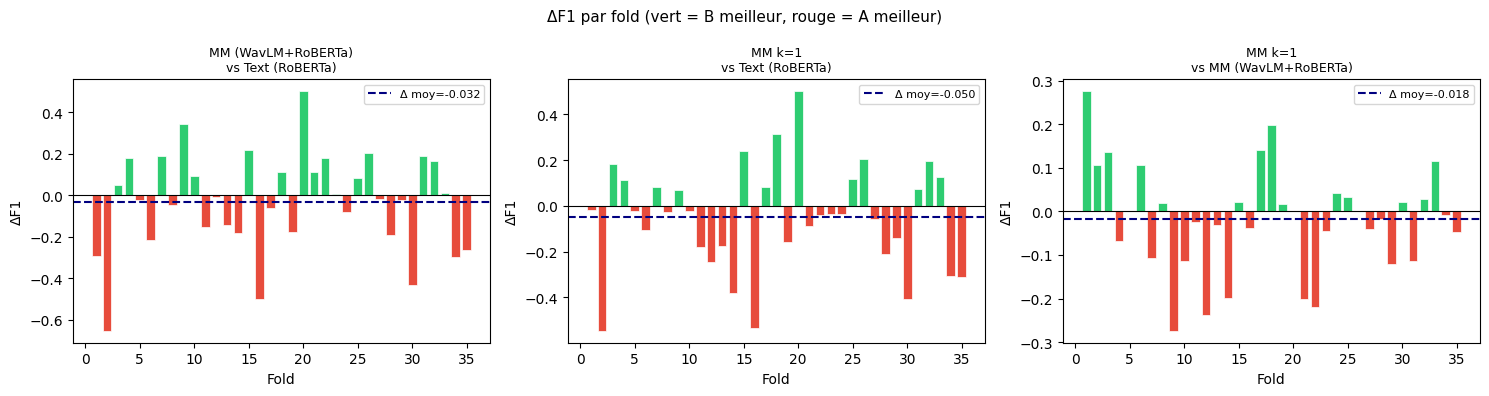

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c in zip(axes, all_comparisons):
    diffs = c['diffs']
    colors_bar = ['#2ecc71' if d > 0 else ('#e74c3c' if d < 0 else '#aaa') for d in diffs]
    ax.bar(range(1, len(diffs) + 1), diffs, color=colors_bar, edgecolor='white', lw=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(c['delta'], color='navy', lw=1.5, linestyle='--',
               label=f"Δ moy={c['delta']:+.3f}")
    ax.set_title(f"{c['model_b']}\nvs {c['model_a']}", fontsize=9)
    ax.set_xlabel('Fold')
    ax.set_ylabel('ΔF1')
    ax.legend(fontsize=8)

plt.suptitle('ΔF1 par fold (vert = B meilleur, rouge = A meilleur)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fold_diffs_35folds.png', dpi=150)
plt.show()

## §5 Export CSV

In [8]:
csv_path = ROOT / 'results' / 'statistical_tests_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f'Saved → {csv_path}')
df_summary

Saved → /workspace/patootie_code/mm_argfallacy/results/statistical_tests_summary.csv


,Modèle A,Modèle B,n,F1_A,F1_B,ΔF1,IC 95%,IC ∋ 0 ?,p Wilcoxon,Sig.,Wins B
0,Text (RoBERTa),MM (WavLM+RoBERTa),35,0.4764,0.4446,-0.0318,"[-0.1100, +0.0453]",oui,0.5654,ns,16
1,Text (RoBERTa),MM k=1,35,0.4764,0.4263,-0.0501,"[-0.1262, +0.0248]",oui,0.2799,ns,13
2,MM (WavLM+RoBERTa),MM k=1,35,0.4446,0.4263,-0.0183,"[-0.0583, +0.0220]",oui,0.3669,ns,15
